# **1. Perkenalan Dataset**


1. **Sumber Dataset**: Sumber dataset saya peroleh dari kaggle yang diupload oleh RAJ PARMAR dengan nama dataset winequalityN melalui link: https://www.kaggle.com/datasets/rajyellow46/wine-quality 
   


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# **3. Memuat Dataset**

In [2]:
# Path Folder
file_path = '../wine_quality_raw/wine-quality.csv'

# Membaca Dataset
df = pd.read_csv(file_path)

# Menampilkan 5 Baris Pertama Dataset
print(df.head())

    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  
0       0.45      8.8        6  
1       0.49      9.5        6  
2       0.4

# **4. Exploratory Data Analysis (EDA)**

In [3]:
# Menampilkan Informasi Umum Dataset
print("Informasi Dataset: ")
df.info()

Informasi Dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
# Melihat Statistik Deskriptif
print(df.describe)

<bound method NDFrame.describe of        type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0     white            7.0             0.270         0.36            20.7   
1     white            6.3             0.300         0.34             1.6   
2     white            8.1             0.280         0.40             6.9   
3     white            7.2             0.230         0.32             8.5   
4     white            7.2             0.230         0.32             8.5   
...     ...            ...               ...          ...             ...   
6492    red            6.2             0.600         0.08             2.0   
6493    red            5.9             0.550         0.10             2.2   
6494    red            6.3             0.510         0.13             2.3   
6495    red            5.9             0.645         0.12             2.0   
6496    red            6.0             0.310         0.47             3.6   

      chlorides  free sulfur dioxide  tot

In [5]:
# Periksa Missing Values
print(df.isnull().sum())

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64


C:\Users\rianp\AppData\Local\Temp\ipykernel_23288\4024210100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


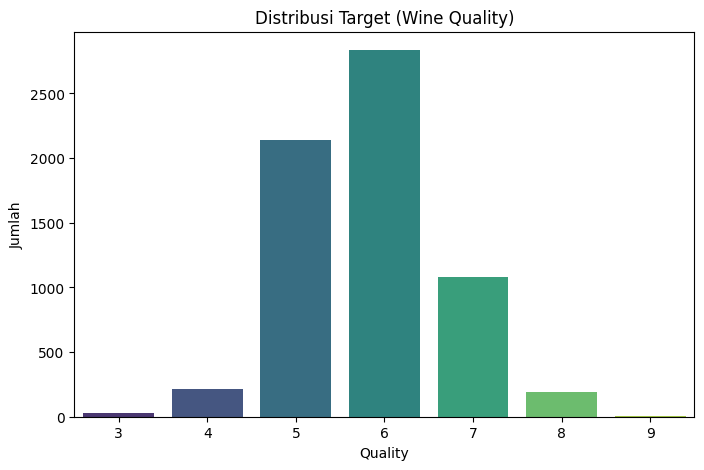

In [6]:
# Visualisasi Distribusi Target ('quality')
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribusi Target (Wine Quality)')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.show()

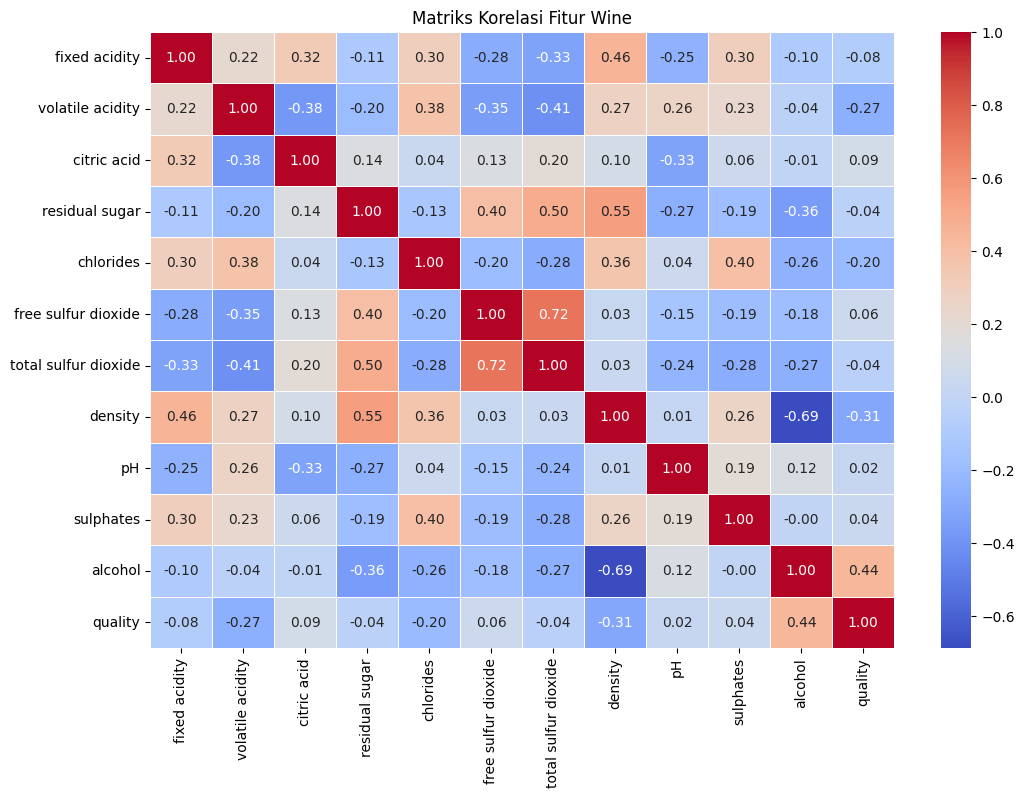

In [7]:
# Heatmap Korelasi Antar Fitur Numerik
plt.figure(figsize=(12, 8))

# Hanya Hitung Korelasi Kolom Numerik
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Wine')
plt.show()

# **5. Data Preprocessing**

In [8]:
# Menangani Missing Values
df_clean = df.dropna().copy()
print(f"Sisa baris setelah drop null: {len(df_clean)} baris")

# Encoding Data Kategorikal
# Kolom 'type' Yang Berisi 'red' dan 'white'. Diubah Menjadi 0 dan 1.
le = LabelEncoder()
df_clean['type'] = le.fit_transform(df_clean['type'])

# Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

# Membagi data Latih dan Data Uji (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nProses Preprocessing Selesai!")
print(f"Dimensi Data Latih (Train): {X_train_scaled.shape}")
print(f"Dimensi Data Uji (Test): {X_test_scaled.shape}")


Sisa baris setelah drop null: 6463 baris

Proses Preprocessing Selesai!
Dimensi Data Latih (Train): (5170, 12)
Dimensi Data Uji (Test): (1293, 12)


# **6. Simpan Data yang Sudah Diproses**

In [10]:
# Menyimpan hasil preprocessing ke CSV
import os
import pandas as pd
output_folder = 'wine_quality_preprocessing'
os.makedirs(output_folder, exist_ok=True)

# Konversi array NumPy
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_df.to_csv(os.path.join(output_folder, 'X_train.csv'), index=False)
X_test_df.to_csv(os.path.join(output_folder, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_folder, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_folder, 'y_test.csv'), index=False)
print('Export berhasil!')


Export berhasil!
